In [6]:
import numpy as np
import matplotlib.pyplot as plt

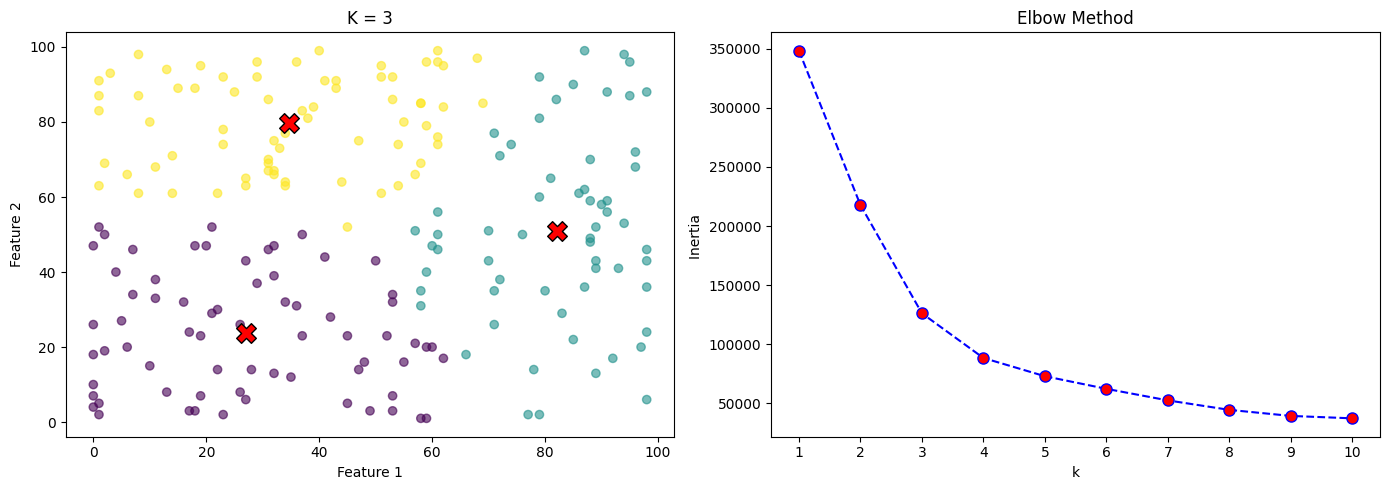

In [7]:
import numpy as np
import matplotlib.pyplot as plt

class KMeans_clt:
    def __init__(self, k=3):
        self.k = k 
        self.centroids = None
        self.inertia_ = 0  

    def euclidean_distance(self, a, b):
        return np.sqrt(np.sum((a - b) ** 2, axis=1))

    def fit(self, X, max_iters=100):
        self.centroids = np.random.uniform(low=np.min(X, axis=0), high=np.max(X, axis=0), size=(self.k, X.shape[1]))
        
        for _ in range(max_iters):
            y = []
            for data_point in X:
                distances = self.euclidean_distance(data_point, self.centroids)
                y.append(np.argmin(distances))
            y = np.array(y)
            
            cluster_indices = [np.where(y == i) for i in range(self.k)]
            cluster_centers = []
            
            for i, indices in enumerate(cluster_indices):
                if len(X[indices]) == 0:
                    cluster_centers.append(self.centroids[i])
                else:
                    cluster_centers.append(np.mean(X[indices], axis=0))
            if np.max(np.abs(self.centroids - np.array(cluster_centers))) < 0.0001:
                break
            else:
                self.centroids = np.array(cluster_centers)

        self.inertia_ = 0
        for i in range(self.k):
            cluster_points = X[y == i]
            if len(cluster_points) > 0:
                self.inertia_ += np.sum((cluster_points - self.centroids[i]) ** 2)

        return y

np.random.seed(42) 
random = np.random.randint(0, 100, (200, 2))
plt.figure(figsize=(14, 5))

kmeans = KMeans_clt(k=3)
labels = kmeans.fit(random)

plt.subplot(1, 2, 1)
plt.scatter(random[:, 0], random[:, 1], c=labels, cmap='viridis', alpha=0.6)
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], c='red', marker='X', s=200, edgecolors='black')
plt.title('K = 3')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')


inertias = []
K_range = range(1, 11) 
for k in K_range:
    km = KMeans_clt(k=k)
    km.fit(random)
    inertias.append(km.inertia_)

plt.subplot(1, 2, 2)
plt.plot(K_range, inertias, marker='o', linestyle='dashed', color='blue', markerfacecolor='red', markersize=8)
plt.title('Elbow Method')
plt.xlabel('k')
plt.ylabel('Inertia ')
plt.xticks(K_range)



plt.tight_layout()
plt.show()

Text(0, 0.5, 'Feature 2')

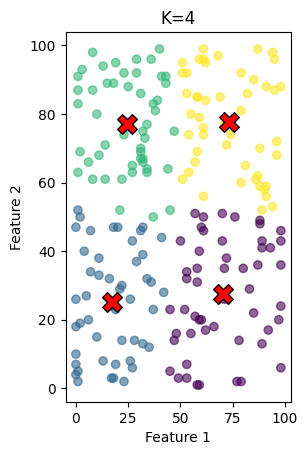

In [8]:
kmeans = KMeans_clt(k=4)
labels = kmeans.fit(random)

plt.subplot(1, 2, 1)
plt.scatter(random[:, 0], random[:, 1], c=labels, cmap='viridis', alpha=0.6)
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], c='red', marker='X', s=200, edgecolors='black')
plt.title('K=4')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')